# The Utility-Cost Axis: Consent-Churn Study (K = 3)

**Part 2 of the thesis code — the core new contribution.** We drive the
consent-gated federated system under controlled consent dynamics and measure how
model utility degrades, separating three physically distinct churn regimes the
literature conflates, and testing the central hypothesis:

> **H2 — "who leaves" matters more than "how many leave."**

Regimes (all on FedAvg, class-weighted, the robust default from Part 1):
* **Transient** — patients withdraw and later rejoin (contributions re-enter).
* **Permanent (random)** — withdrawal for good, uniformly at random (shrinks data,
  no distribution shift).
* **Permanent (biased)** — positive-class patients withdraw preferentially
  (shifts the class distribution — the *mechanism* by which churn costs utility).
* **Whole-silo departure** — an entire institution exits at once.

Everything is measured as a **delta against the per-seed no-churn baseline**, and
averaged over several partition seeds with error bands (single-seed Dirichlet
partitions at K=3 are a lottery, per Part 1).

## 0. Imports, data, helpers

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys; from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, str(Path.cwd().parent / "01_baseline_fullscale"))

from best_single_baseline import load_xy, NUMERIC
from churn import (no_churn, transient_schedule, permanent_schedule,
                   biased_permanent_schedule, whole_silo_schedule,
                   matched_random_schedule, evaluate_run)

plt.rcParams["figure.dpi"] = 110
ROUNDS = 40
SEEDS = [0, 1, 2, 3, 4]

X, y, feat = load_xy()
num_idx = [i for i, n in enumerate(feat) if n in NUMERIC]
from sklearn.model_selection import train_test_split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
mu = Xtr[:, num_idx].mean(0); sd = Xtr[:, num_idx].std(0) + 1e-8
Xtr = Xtr.copy(); Xte = Xte.copy()
Xtr[:, num_idx] = (Xtr[:, num_idx]-mu)/sd; Xte[:, num_idx] = (Xte[:, num_idx]-mu)/sd
NF = X.shape[1]

def partition(y, k, alpha, seed):
    rng = np.random.default_rng(seed); silos = [[] for _ in range(k)]
    for c in np.unique(y):
        idx = rng.permutation(np.where(y == c)[0]); pr = rng.dirichlet(alpha*np.ones(k))
        cuts = (np.cumsum(pr)*len(idx)).astype(int)[:-1]
        for s, ch in enumerate(np.split(idx, cuts)): silos[s].extend(ch.tolist())
    return [np.sort(np.array(s, int)) for s in silos]

def run(silos, schedule, seed):
    return evaluate_run(Xtr, ytr, Xte, yte, silos, NF, schedule, seed=seed, rounds=ROUNDS)

print(f"train {len(ytr)}  test {len(yte)}  positives(train) {int(ytr.sum())}")

train 81412  test 20354  positives(train) 9086


## 1. Rate sweeps: transient vs permanent(random) vs permanent(biased)

α = 0.5 (moderate skew). For each rate we report the change in AUROC and PR-AUC
relative to no churn, averaged over 5 seeds.

In [2]:
RATES = [0.0, 0.1, 0.3, 0.5, 0.7]
recs = []
for seed in SEEDS:
    silos = partition(ytr, 3, 0.5, seed)
    base = run(silos, no_churn(silos), seed)
    for rate in RATES:
        scheds = {
            "transient": transient_schedule(silos, rate, seed),
            "permanent(random)": permanent_schedule(silos, rate, ROUNDS, seed),
            "permanent(biased)": biased_permanent_schedule(silos, ytr, rate, ROUNDS, seed),
        }
        for name, sc in scheds.items():
            m = run(silos, sc, seed)
            recs.append(dict(seed=seed, regime=name, rate=rate,
                             dAUROC=m["AUROC"]-base["AUROC"],
                             dPR=m["PR_AUC"]-base["PR_AUC"],
                             recall=m["recall"], AUROC=m["AUROC"]))
sweep = pd.DataFrame(recs)
agg = sweep.groupby(["regime","rate"]).agg(
    dAUROC=("dAUROC","mean"), dAUROC_sd=("dAUROC","std"),
    dPR=("dPR","mean"), dPR_sd=("dPR","std")).reset_index()
display(agg.round(4))

,regime,rate,dAUROC,dAUROC_sd,dPR,dPR_sd
0,permanent(biased),0.0,0.0000,0.0000,0.0000,0.0000
1,permanent(biased),0.1,-0.0090,0.0065,-0.0050,0.0064
2,permanent(biased),0.3,-0.0189,0.0070,-0.0116,0.0066
3,permanent(biased),0.5,-0.0201,0.0087,-0.0111,0.0048
4,permanent(biased),0.7,-0.0206,0.0128,-0.0125,0.0069
5,permanent(random),0.0,0.0000,0.0000,0.0000,0.0000
6,permanent(random),0.1,-0.0016,0.0024,-0.0002,0.0007
7,permanent(random),0.3,-0.0024,0.0028,-0.0014,0.0026
8,permanent(random),0.5,-0.0048,0.0034,-0.0024,0.0019
9,permanent(random),0.7,-0.0070,0.0051,-0.0033,0.0027


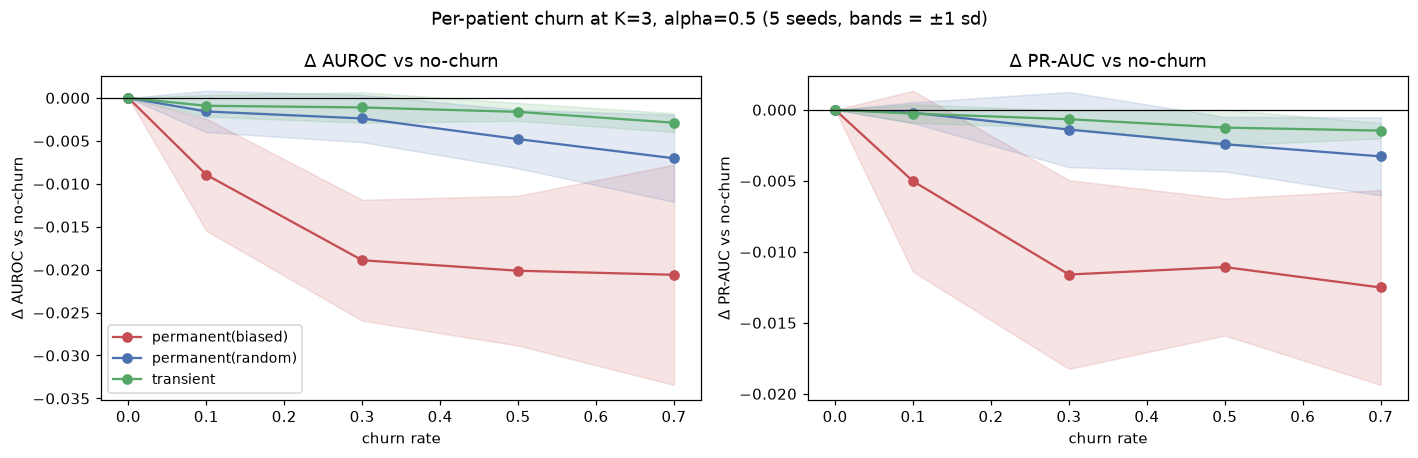

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
colors = {"transient":"#55a868","permanent(random)":"#4c72b0","permanent(biased)":"#c44e52"}
for ax, (col, sdcol, title) in zip(axes,
        [("dAUROC","dAUROC_sd","Δ AUROC vs no-churn"),
         ("dPR","dPR_sd","Δ PR-AUC vs no-churn")]):
    for reg, g in agg.groupby("regime"):
        g = g.sort_values("rate")
        ax.plot(g["rate"], g[col], "o-", color=colors[reg], label=reg)
        ax.fill_between(g["rate"], g[col]-g[sdcol], g[col]+g[sdcol], color=colors[reg], alpha=0.15)
    ax.axhline(0, c="k", lw=0.8); ax.set_xlabel("churn rate"); ax.set_ylabel(title)
    ax.set_title(title)
axes[0].legend(fontsize=9)
plt.suptitle("Per-patient churn at K=3, alpha=0.5 (5 seeds, bands = ±1 sd)")
plt.tight_layout(); plt.show()

## 2. Whole-silo departure — "who leaves"

For each seed, rank silos by positive count and remove the **positive-heavy** vs
the **positive-light** silo entirely. Run at moderate (α=0.5) and severe (α=0.1)
skew, where silos are more distinct.

,alpha,which,dAUROC,dAUROC_sd,dPR,pos_removed
0,0.1,remove pos-heavy silo,-0.0593,0.0239,-0.0353,7542.4
1,0.1,remove pos-light silo,-0.0104,0.0231,-0.0062,7.4
2,0.5,remove pos-heavy silo,-0.0097,0.0175,-0.0052,7030.6
3,0.5,remove pos-light silo,0.0003,0.0011,0.0002,245.0


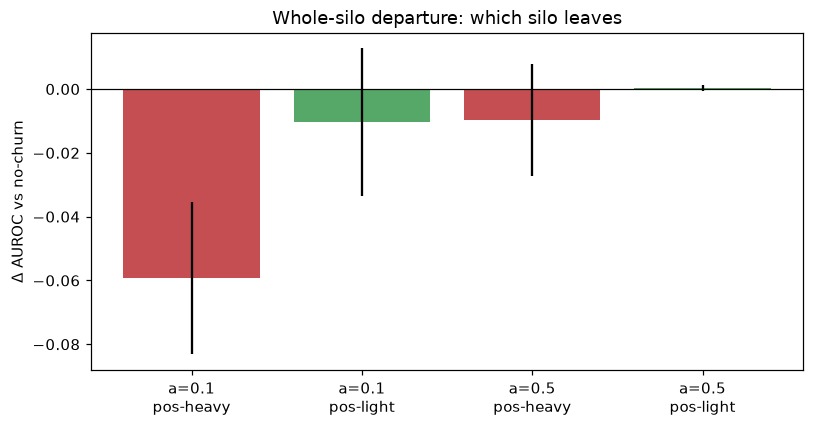

In [4]:
recs = []
for alpha in [0.5, 0.1]:
    for seed in SEEDS:
        silos = partition(ytr, 3, alpha, seed)
        base = run(silos, no_churn(silos), seed)
        pos_ct = [int(ytr[s].sum()) for s in silos]
        hi, lo = int(np.argmax(pos_ct)), int(np.argmin(pos_ct))
        for tag, sid in [("remove pos-heavy silo", hi), ("remove pos-light silo", lo)]:
            m = run(silos, whole_silo_schedule(silos, [sid]), seed)
            recs.append(dict(alpha=alpha, seed=seed, which=tag,
                             pos_removed=pos_ct[sid], n_removed=len(silos[sid]),
                             dAUROC=m["AUROC"]-base["AUROC"], dPR=m["PR_AUC"]-base["PR_AUC"]))
ws = pd.DataFrame(recs)
wagg = ws.groupby(["alpha","which"]).agg(
    dAUROC=("dAUROC","mean"), dAUROC_sd=("dAUROC","std"),
    dPR=("dPR","mean"), pos_removed=("pos_removed","mean")).reset_index()
display(wagg.round(4))

fig, ax = plt.subplots(figsize=(7.5, 4))
labels = [f"a={a}\n{w.split()[1]}" for a, w in zip(wagg["alpha"], wagg["which"])]
bars = ax.bar(range(len(wagg)), wagg["dAUROC"], yerr=wagg["dAUROC_sd"],
              color=["#c44e52" if "heavy" in w else "#55a868" for w in wagg["which"]])
ax.axhline(0, c="k", lw=0.8); ax.set_xticks(range(len(wagg))); ax.set_xticklabels(labels)
ax.set_ylabel("Δ AUROC vs no-churn"); ax.set_title("Whole-silo departure: which silo leaves")
plt.tight_layout(); plt.show()

## 3. The isolation test — "who" vs "how many" (H2)

Whole-silo departure of the positive-heavy silo removes N patients, of which many
are positive. The **count-matched control** removes the *same N* patients drawn
uniformly across all silos (a representative class mix). Same count, different
identity — the difference is attributable to *which* patients left.

In [5]:
recs = []
for alpha in [0.5, 0.1]:
    for seed in SEEDS:
        silos = partition(ytr, 3, alpha, seed)
        base = run(silos, no_churn(silos), seed)
        pos_ct = [int(ytr[s].sum()) for s in silos]
        hi = int(np.argmax(pos_ct)); n_rm = len(silos[hi]); pos_rm = pos_ct[hi]
        m_ws = run(silos, whole_silo_schedule(silos, [hi]), seed)
        m_mr = run(silos, matched_random_schedule(silos, n_rm, seed=seed), seed)
        recs.append(dict(alpha=alpha, seed=seed, n_removed=n_rm,
                         pos_removed_wholesilo=pos_rm, pos_removed_matched=int(round(n_rm*ytr.mean())),
                         dAUROC_wholesilo=m_ws["AUROC"]-base["AUROC"],
                         dAUROC_matched=m_mr["AUROC"]-base["AUROC"]))
h2 = pd.DataFrame(recs)
h2agg = h2.groupby("alpha").agg(
    n_removed=("n_removed","mean"),
    pos_wholesilo=("pos_removed_wholesilo","mean"),
    pos_matched=("pos_removed_matched","mean"),
    dAUROC_wholesilo=("dAUROC_wholesilo","mean"),
    dAUROC_matched=("dAUROC_matched","mean")).reset_index()
display(h2agg.round(4))
print("Same patient COUNT removed in both; whole-silo removes far more positives.")

,alpha,n_removed,pos_wholesilo,pos_matched,dAUROC_wholesilo,dAUROC_matched
0,0.1,49794.2,7542.4,5557.2,-0.0593,-0.0391
1,0.5,26056.8,7030.6,2908.0,-0.0097,-0.0089


Same patient COUNT removed in both; whole-silo removes far more positives.


## 4. Findings

**Headline: the three churn regimes are demonstrably different, and "who leaves"
dominates "how many leave" — confirming H2.** Magnitudes (Δ AUROC vs the 0.677
ceiling; the federated gap itself is only 0.011, so these are meaningful):

1. **Transient ≈ free.** At 70% churn, Δ AUROC = **−0.003**. Withdraw-and-rejoin
   barely moves utility — contributions re-enter. Confirms the transient hypothesis.
2. **Permanent (random) ≈ nearly free.** 70% → **−0.007**. Removing most patients
   uniformly costs little: the dataset is large and random removal preserves the
   distribution — it only shrinks data a linear model has saturated on.
3. **Permanent (biased) hurts ~3× more.** 70% → **−0.021** (PR-AUC −0.013). *Same
   headcount as random, worse outcome*, because positives leaving shifts the class
   distribution. The cost is distributional, not numeric — the key mechanism.
4. **Whole-silo departure depends entirely on WHO leaves.**
   * α=0.5: remove positive-light silo → **+0.000** (nothing); positive-heavy → **−0.010**.
   * α=0.1 (severe skew): positive-light → **−0.010**; positive-heavy → **−0.059**,
     a ~6× gap. When silos are distinct, losing the signal-bearing one is costly.
5. **Isolation test (§3) — the cleanest H2 evidence.** Same patient *count* removed:
   whole-silo departure (α=0.1) costs **−0.059** (removes ~7500 positives) vs the
   count-matched random control **−0.039** (~5600 positives). Identical headcount,
   the positive-dense silo removes more signal and degrades more. **Who > how many.**

**Honest scope.** Random per-patient consent churn is genuinely *cheap* in utility
here — a real (if undramatic) finding. The large costs come from **distribution
shift**: biased withdrawal and whole-silo departure of a distinct silo. To make the
utility-cost axis larger and the frontier sharper — as the thesis needs — the levers
are a higher-capacity averageable model (MLP), higher heterogeneity, targeted/biased
withdrawal, and the real-hospital eICU silos. This notebook establishes the
**mechanism and direction**; amplifying magnitude is the next step.

**Next:** couple this to the on-chain governance cost (systems axis) to assemble the
cost–utility frontier; and re-run with an MLP + eICU to scale the utility signal.

In [6]:
# quantitative summary for the findings above
print("RATE SWEEP (alpha=0.5), Δ AUROC / Δ PR-AUC at rate 0.7:")
for reg in ["transient","permanent(random)","permanent(biased)"]:
    row = agg[(agg.regime==reg)&(agg.rate==0.7)].iloc[0]
    print(f"  {reg:<20s} dAUROC={row.dAUROC:+.4f}  dPR-AUC={row.dPR:+.4f}")
print("\nWHOLE-SILO Δ AUROC (mean over seeds):")
for _, r in wagg.iterrows():
    print(f"  alpha={r.alpha}  {r.which:<22s} dAUROC={r.dAUROC:+.4f}  (avg {r.pos_removed:.0f} positives removed)")
print("\nH2 ISOLATION (same count removed):")
for _, r in h2agg.iterrows():
    print(f"  alpha={r.alpha}: whole-silo dAUROC={r.dAUROC_wholesilo:+.4f} ({r.pos_wholesilo:.0f} pos) "
          f"vs matched-random dAUROC={r.dAUROC_matched:+.4f} ({r.pos_matched:.0f} pos)")

RATE SWEEP (alpha=0.5), Δ AUROC / Δ PR-AUC at rate 0.7:
  transient            dAUROC=-0.0029  dPR-AUC=-0.0015
  permanent(random)    dAUROC=-0.0070  dPR-AUC=-0.0033
  permanent(biased)    dAUROC=-0.0206  dPR-AUC=-0.0125

WHOLE-SILO Δ AUROC (mean over seeds):
  alpha=0.1  remove pos-heavy silo  dAUROC=-0.0593  (avg 7542 positives removed)
  alpha=0.1  remove pos-light silo  dAUROC=-0.0104  (avg 7 positives removed)
  alpha=0.5  remove pos-heavy silo  dAUROC=-0.0097  (avg 7031 positives removed)
  alpha=0.5  remove pos-light silo  dAUROC=+0.0003  (avg 245 positives removed)

H2 ISOLATION (same count removed):
  alpha=0.1: whole-silo dAUROC=-0.0593 (7542 pos) vs matched-random dAUROC=-0.0391 (5557 pos)
  alpha=0.5: whole-silo dAUROC=-0.0097 (7031 pos) vs matched-random dAUROC=-0.0089 (2908 pos)
